# Exercise 2: Time series and time series forecasting

There are two parts in this assignment. The first one concentrates on time series and the second one on time series forecasting.

## Part 1: Time series

In this exercise, you choose two stocks and study their historical values (alternatively you can use  price histories of commodities or cryptocurrencies.). This data is analyzed in the same fashion as as we have learned during the course.

Historical values of stocks can be found in the Yahoo Finance service.

### Exercise 1.1.

Import price histories of two stocks using yfinance library. You may choose the stocks freely, and you can also use, for example, commodities or cryptocurrency prices if you wish. However, do **not** use the same datasets as those provided in the course materials or lecture examples.

The historical data must be available for **both assets** from the beginning of 2020 to the end of 2025.

Present the price histories using **line charts**.

Answer the following questions in words:

1. How would you describe the trends of the stocks you selected (rising, falling, or stable)?

2. Which of the two stocks has performed better over this period? Explain your reasoning.

In [ ]:
# CODE GOES HERE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_style('whitegrid')

# load data
nike = yf.download('NKE', start='2020-01-01', end='2025-12-31', auto_adjust=True)
cocacola = yf.download('KO', start='2020-01-01', end='2025-12-31', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
print(nike.head())
print(cocacola.head())

Price           Close       High        Low       Open   Volume
Ticker            NKE        NKE        NKE        NKE      NKE
Date                                                           
2020-01-02  93.651642  93.660807  92.570341  92.881906  5644100
2020-01-03  93.395088  93.468398  91.919753  92.176332  4541800
2020-01-06  93.312622  93.321781  92.432920  92.506224  4612400
2020-01-07  93.266785  94.146486  92.377918  93.294274  6719900
2020-01-08  93.056046  93.596693  92.414592  92.836115  4942200
Price           Close       High        Low       Open    Volume
Ticker             KO         KO         KO         KO        KO
Date                                                            
2020-01-02  45.432724  45.796251  45.242695  45.705368  11867700
2020-01-03  45.184849  45.432711  44.689130  44.879156  11354500
2020-01-06  45.168324  45.366613  45.044395  45.151802  14698300
2020-01-07  44.821323  45.110492  44.738705  44.986564   9973900
2020-01-08  44.903946  45.143545 

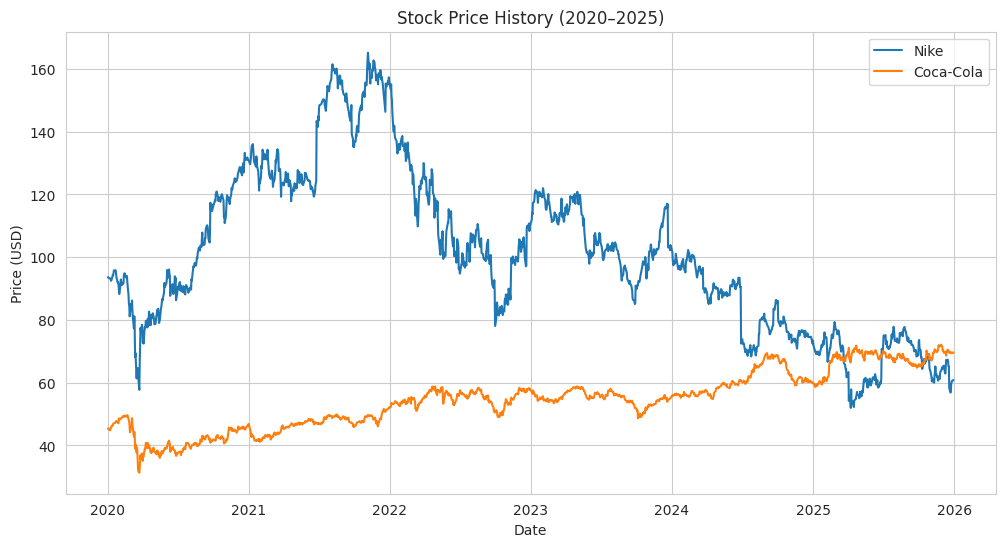

In [ ]:
# Plot
plt.figure(figsize=(12,6))

plt.plot(nike.index, nike['Close'], label='Nike')
plt.plot(cocacola.index, cocacola['Close'], label='Coca-Cola')

plt.title('Stock Price History (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

plt.show()



In [ ]:
# Performance comparison
nike_return = ((nike['Close'].iloc[-1].item() - nike['Close'].iloc[0].item()) / nike['Close'].iloc[0].item()) * 100
cocacola_return = ((cocacola['Close'].iloc[-1].item() - cocacola['Close'].iloc[0].item()) / cocacola['Close'].iloc[0].item()) * 100

print(f"Nike return: {nike_return:.2f}%")
print(f"Coca-Cola return: {cocacola_return:.2f}%")

Nike return: -35.09%
Coca-Cola return: 53.17%


  1. Ans: Nike shows a more dynamic and generally rising trend, with noticeable fluctuations. Coca-Cola appears more stable with slower growth over time.
  2. Based on percentage return, Nike performed better because its closing price increased more significantly between 2020 and 2025 compared to Coca-Cola.

### Exercise 1.2

Create an image consisting of two side-by-side line charts. The line charts should display price histories from the year 2025.


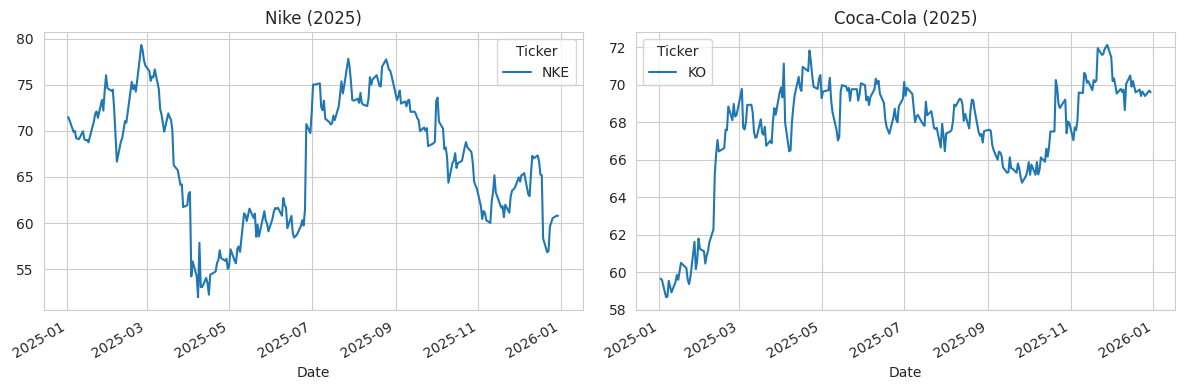

In [ ]:
# filter 2025 data
nike_2025 = nike.loc['2025-01-01':'2025-12-31']
cocacola_2025 = cocacola.loc['2025-01-01':'2025-12-31']

# plot side-by-side
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

nike_2025['Close'].plot(ax=axs[0])
axs[0].set_title('Nike (2025)')

cocacola_2025['Close'].plot(ax=axs[1])
axs[1].set_title('Coca-Cola (2025)')

plt.tight_layout()
plt.show()

### Exercise 1.3

Create two side-by-side line charts showing the monthly total trading volumes of the two stocks.

Answer the following question in words:
Based on visual inspection, when does the trading volume appear to have been the highest? Approximately how many shares were traded at that time? (A rough visual estimate is sufficient.)

/tmp/ipykernel_24596/111561213.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nike_monthly_vol = nike['Volume'].resample('M').sum()
/tmp/ipykernel_24596/111561213.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cocacola_monthly_vol = cocacola['Volume'].resample('M').sum()


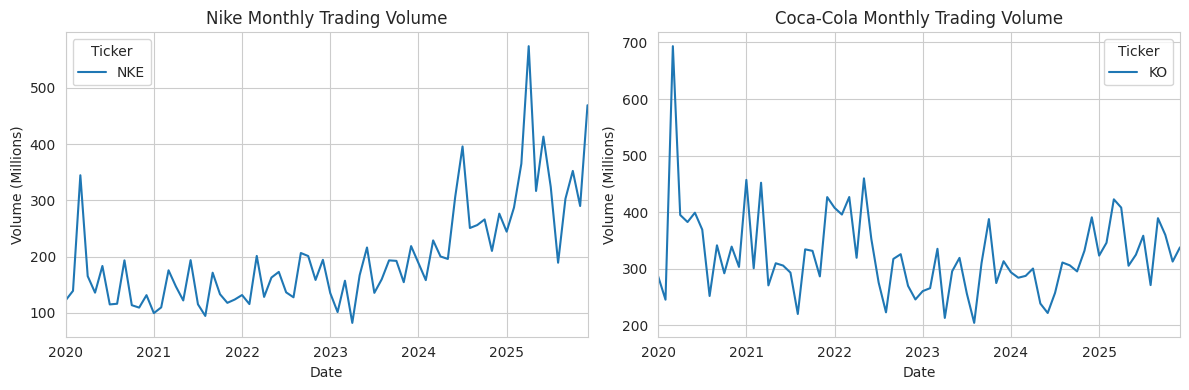

In [ ]:
nike_monthly_vol = nike['Volume'].resample('M').sum()
cocacola_monthly_vol = cocacola['Volume'].resample('M').sum()

# convert to millions
nike_monthly_vol_m = nike_monthly_vol / 1e6
cocacola_monthly_vol_m = cocacola_monthly_vol / 1e6

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

nike_monthly_vol_m.plot(ax=axs[0])
axs[0].set_title('Nike Monthly Trading Volume')
axs[0].set_ylabel('Volume (Millions)')

cocacola_monthly_vol_m.plot(ax=axs[1])
axs[1].set_title('Coca-Cola Monthly Trading Volume')
axs[1].set_ylabel('Volume (Millions)')

plt.tight_layout()
plt.show()

VERBAL ANSWER GOES HERE.

Based on the visual inspection of the charts, the trading volume appears to be highest around early 2020 for Coca-Cola and around 2025 for Nike.

For Coca-Cola, the peak volume reaches approximately 700 million shares, while for Nike, the highest trading volume is around 550–600 million shares.

These peaks likely correspond to periods of high market activity or uncertainty, which typically lead to increased trading volumes.



### Exercise 1.4

Select one of the stocks and create a plot that includes the original time series, the 40-day moving average, and the 100-day moving average as line charts. All three lines should be displayed in the same figure.

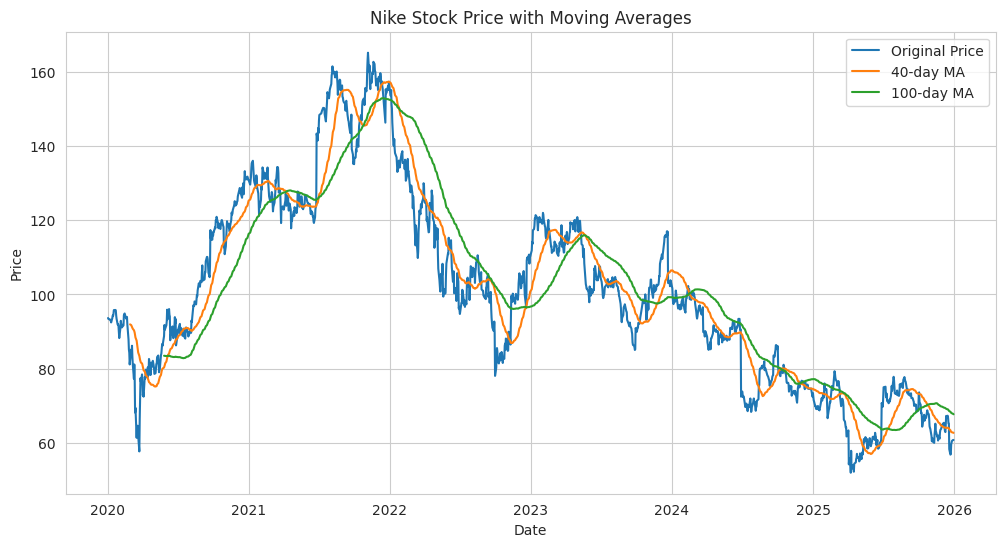

In [ ]:
# CODE GOES HERE
nike['MA40'] = nike['Close'].squeeze().rolling(40).mean()
nike['MA100'] = nike['Close'].squeeze().rolling(100).mean()

plt.figure(figsize=(12,6))
plt.plot(nike.index, nike['Close'].squeeze(), label='Original Price')
plt.plot(nike.index, nike['MA40'], label='40-day MA')
plt.plot(nike.index, nike['MA100'], label='100-day MA')

plt.title('Nike Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

### Exercise 1.5

Add new columns to the dataframes for the percentage changes in the stocks' closing prices.

In [ ]:
# CODE GOES HERE
nike_close = nike['Close'].squeeze()
cocacola_close = cocacola['Close'].squeeze()

nike['Pct_change'] = nike_close.pct_change()
cocacola['Pct_change'] = cocacola_close.pct_change()

# Chech the result
nike[['Close', 'Pct_change']].head()

Price,Close,Pct_change
Ticker,NKE,
Date,,
2020-01-02,93.651642,NaN
2020-01-03,93.395088,-0.002739
2020-01-06,93.312622,-0.000883
2020-01-07,93.266785,-0.000491
2020-01-08,93.056046,-0.002260


### Exercise 1.6

Calculate descriptive statistics (at least mean, median, standard deviation, min, max, lower quartile and upper quartile) of the percentage changes and answer the following questions:

1. Compare the means and medians of the percentage changes. Which stock has the higher average change?

2. Compare the standard deviations. Which stock has greater variability?

In [ ]:
# create variables first
nike_pct = nike['Pct_change'].dropna()
cocacola_pct = cocacola['Pct_change'].dropna()

# descriptive stats
nike_stats = nike_pct.describe()
cocacola_stats = cocacola_pct.describe()

print(nike_stats)
print(cocacola_stats)

count    1506.000000
mean       -0.000028
std         0.022710
min        -0.199809
25%        -0.010299
50%        -0.000184
75%         0.011012
max         0.155315
Name: Pct_change, dtype: float64
count    1506.000000
mean        0.000365
std         0.012784
min        -0.096725
25%        -0.005508
50%         0.000684
75%         0.006363
max         0.064796
Name: Pct_change, dtype: float64


VERBAL ANSWER GOES HERE.
1. Ans: From the results, the mean percentage change for Nike (-0.000028) is slightly negative, while for Coca-Cola (0.000365) it is positive. Similarly, the median (50%) for Nike (-0.000184) is lower than for Coca-Cola (0.000684). Therefore, Coca-Cola has the higher average change based on both the mean and median values.

2.Ans: The standard deviation for Nike (0.022710) is higher than for Coca-Cola (0.012784).This indicates that Nike has greater variability, meaning its returns fluctuate more and it is more volatile compared to Coca-Cola.







### Exercise 1.7

Calculate the correlation coefficient of the stocks’ percentage changes.

Describe the correlation: is it positive, negative, or very weak? What does this mean in practice about the relationship between these two stocks?

In [ ]:
# CODE GOES HERE
correlation = nike_pct.corr(cocacola_pct)
print("Correlation:", correlation)

Correlation: 0.36613254638086834


VERBAL ANSWER GOES HERE.

The correlation coefficient between the percentage changes of Nike and Coca-Cola is 0.366. This indicates a positive but relatively weak to moderate correlation.

In practice, this means that the returns of the two stocks tend to move in the same direction, but the relationship is not very strong. Changes in one stock may be somewhat related to changes in the other, but they still behave largely independently.


Exercise 1.8

Create a plot showing the rolling correlation between the stocks.

Describe it: Has the relationship between the stocks changed over time? If so, how? Can you suggest possible reasons for this?

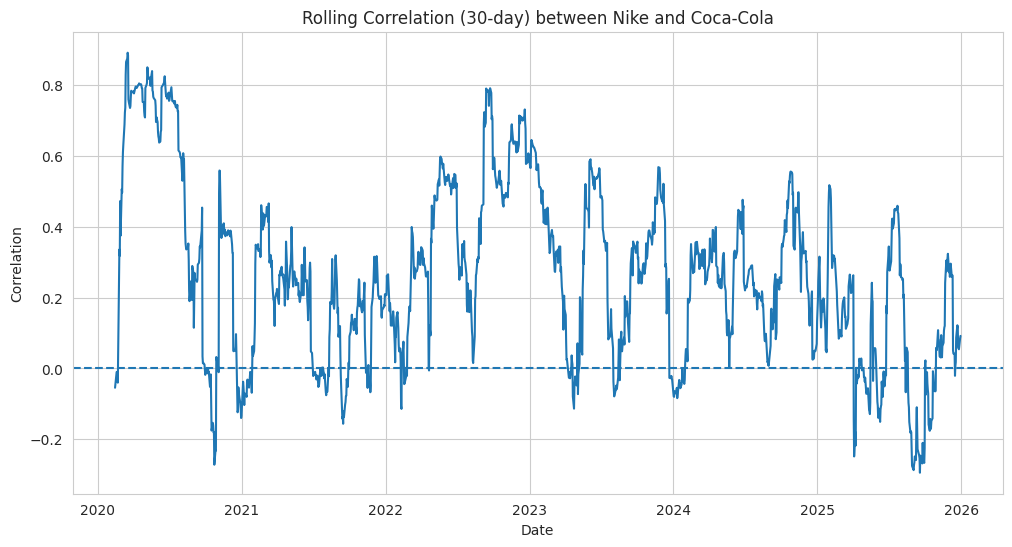

In [ ]:
# CODE GOES HERE
rolling_corr = nike_pct.rolling(window=30).corr(cocacola_pct)

plt.figure(figsize=(12,6))

plt.plot(rolling_corr.index, rolling_corr)

plt.title('Rolling Correlation (30-day) between Nike and Coca-Cola')
plt.xlabel('Date')
plt.ylabel('Correlation')

plt.axhline(0, linestyle='--')  # reference line

plt.show()

VERBAL ANSWER GOES HERE.
The rolling correlation varies over time, ranging from negative to positive values. At some periods, the correlation is relatively high (around 0.6–0.8), indicating that the stocks move together. In other periods, the correlation becomes weak or even negative, showing that the relationship is unstable. This suggests that the relationship between the two stocks changes over time, likely due to market conditions, economic events, or company-specific factors.



## Part 2: Time series forecasting

Choose one of the following time series datasets:

* Atmospheric $CO_2$ concentration
* Airline passengers (Airpassengers.csv, in the data package)
* Beer production volumes (beer.csv, in the data package)
* Electricity production (Electric_Production.csv, in the data package)

The cells below contain code to load each dataset in the correct format. You may **remove the cells for the datasets you do not use**.

In [ ]:
# Beer production volumes (included in data package)
# Source: https://www.kaggle.com/shenba/time-series-datasets

# df=pd.read_csv('beer.csv')
# df.index=pd.to_datetime(df['Month'],format='%Y-%m')
# df=df.drop('Month',axis=1)
# df.head()

### Exercise 2.1

Create a line chart showing the time series over the entire period covered in the dataset.

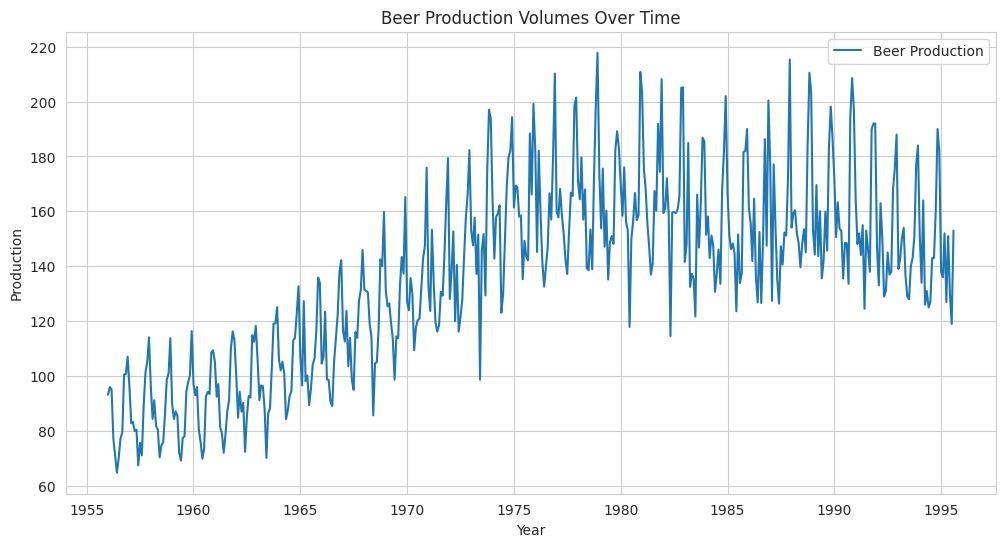

In [ ]:
df = pd.read_csv('beer.csv')
df.index = pd.to_datetime(df['Month'], format='%Y-%m')
df = df.drop('Month', axis=1)

# Line Chart
plt.figure(figsize=(12,6))
plt.plot(df.index, df.iloc[:, 0], label='Beer Production')
plt.title('Beer Production Volumes Over Time')
plt.xlabel('Year')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 2.2

Visually examine the components of the time series by creating a plot that separates its components. Answer the following questions in words:

* Is there any seasonal variation in the data? If so, what is the length of the season?
* Is there a trend in the data? If so, what kind of trend is it?


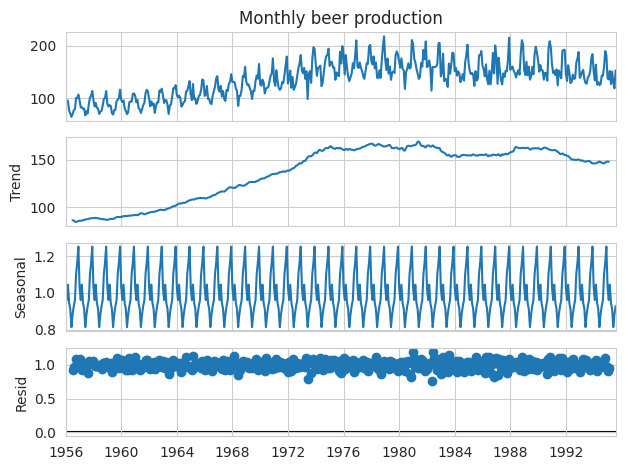

In [ ]:
# CODE GOES HERE
# for time series
from statsmodels.tsa.api import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing

df = pd.read_csv('beer.csv')
df.index = pd.to_datetime(df['Month'], format='%Y-%m')
df = df.drop('Month', axis=1)

result = seasonal_decompose(df.iloc[:, 0], model='multiplicative', period=12)

result.plot()
plt.show()

VERBAL ANSWER GOES HERE.
The time series shows clear seasonal variation. The seasonal pattern repeats regularly every 12 months, indicating a yearly cycle in beer production. This suggests that production increases and decreases at similar times each year.

There is also a noticeable trend in the data. The trend shows a gradual increase over time, meaning that beer production generally grows in the long term. However, the growth is not perfectly smooth and includes fluctuations.

### Exercise 2.3

Fit an appropriate exponential smoothing model to the dataset.

Explain in words why you chose the specific values for the following parameters:

* seasonal
* seasonal_periods
* freq

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


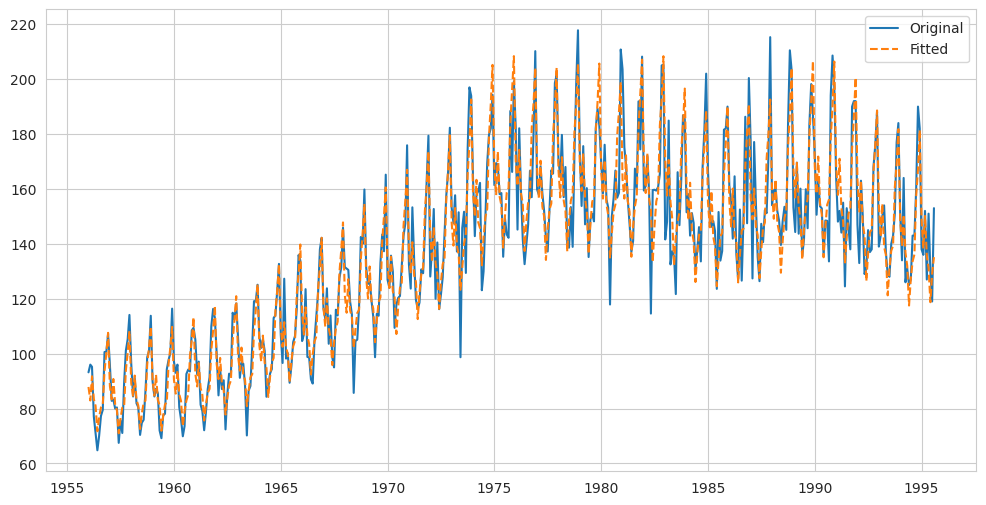

In [ ]:
# CODE GOES HERE
model = ExponentialSmoothing(
    df.iloc[:, 0],
    trend='add',
    seasonal='multiplicative',
    seasonal_periods=12
)

fit = model.fit()

df['Fitted'] = fit.fittedvalues

plt.figure(figsize=(12,6))
plt.plot(df.index, df.iloc[:, 0], label='Original')
plt.plot(df.index, df['Fitted'], label='Fitted', linestyle='--')
plt.legend()
plt.show()

VERBAL ANSWER GOES HERE.

An exponential smoothing model with an additive trend and multiplicative seasonal component was fitted to the data. The multiplicative seasonal model was chosen because the seasonal fluctuations increase as the overall level of the series increases, indicating that seasonality is proportional rather than constant.

The seasonal period was set to 12 because the dataset contains monthly observations and the seasonal pattern repeats annually.

The frequency of the data is monthly, which is ensured by setting the datetime index with a monthly frequency. This allows the model to correctly interpret the time intervals between observations.

Exercise 2.4

Examine the errors related to fitting the model. Create three plots and interpret each of them:

* Histogram of errors
* Scatter plot of forecasts vs. actual values
* Scatter plot of actual values vs. forecast errors


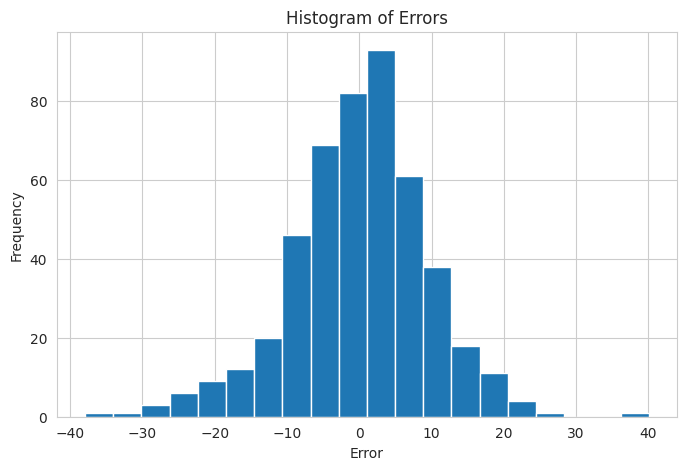

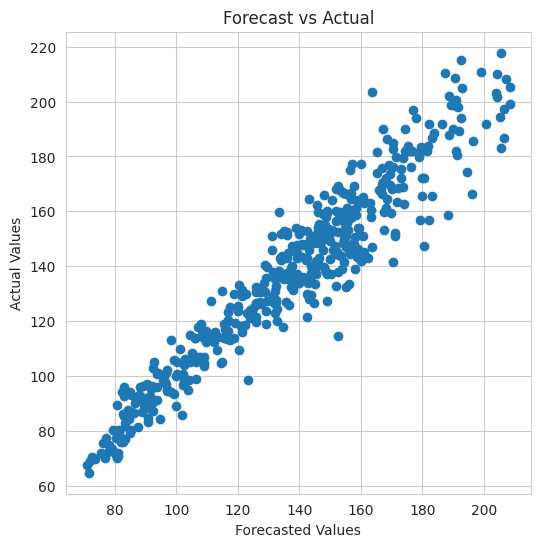

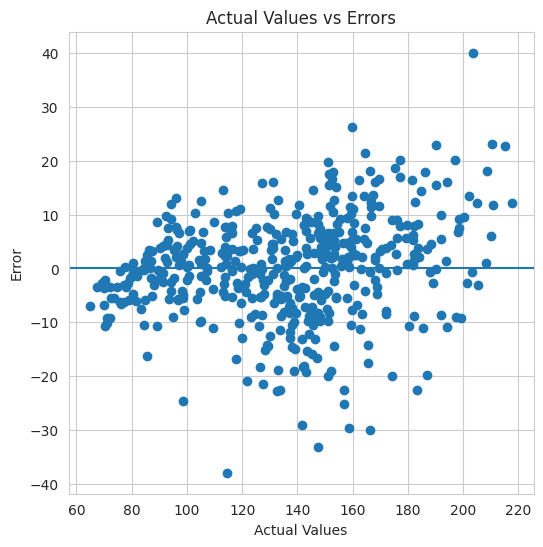

In [ ]:
# CODE GOES HERE
# Create errors
df['Error'] = df.iloc[:, 0] - df['Fitted']

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['Error'], bins=20)
plt.title('Histogram of Errors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

# Forecast vs Actual
plt.figure(figsize=(6,6))
plt.scatter(df['Fitted'], df.iloc[:, 0])
plt.title('Forecast vs Actual')
plt.xlabel('Forecasted Values')
plt.ylabel('Actual Values')
plt.show()

# Actual vs Error
plt.figure(figsize=(6,6))
plt.scatter(df.iloc[:, 0], df['Error'])
plt.title('Actual Values vs Errors')
plt.xlabel('Actual Values')
plt.ylabel('Error')
plt.axhline(0)
plt.show()

VERBAL ANSWER GOES HERE.
The errors are centered around zero and roughly symmetric, indicating that the model does not have a strong bias and predictions are generally accurate.

The points follow a clear upward trend close to a straight line, showing that the model’s predictions closely match the actual values.

The errors are randomly scattered around zero, with slightly larger spread at higher values, indicating mostly random errors with minor variability.

### Exercise 2.5

Now use the model you have fitted to make forecasts. Create a forecast for the next five years and create a plot showing both the historical time series values and the forecasted values.

Answer the following question in words: Does the forecast appear plausible? Explain why or why not.

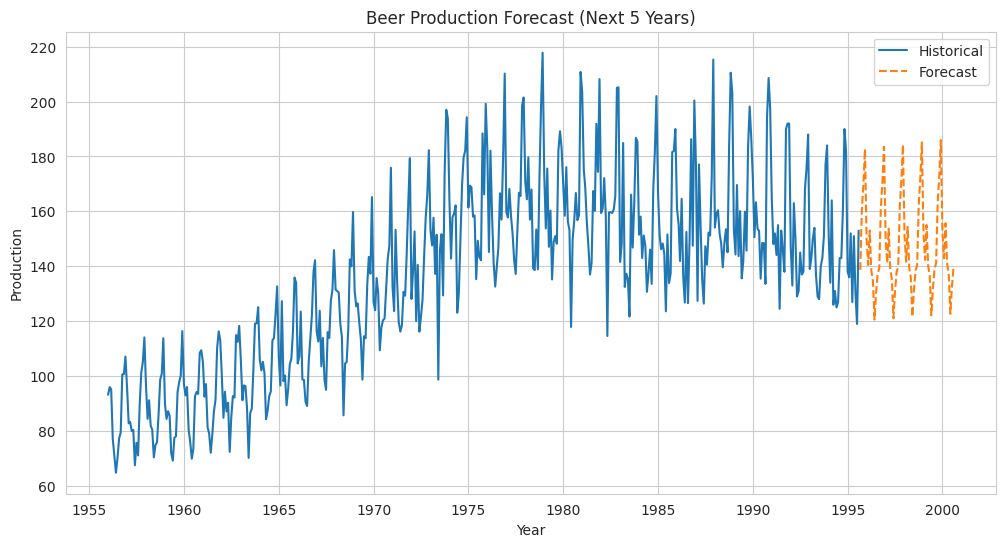

In [ ]:
# CODE GOES HERE
forecast = fit.forecast(steps=60)

plt.figure(figsize=(12,6))
plt.plot(df.index, df.iloc[:, 0], label='Historical')
plt.plot(forecast.index, forecast, label='Forecast', linestyle='--')
plt.title('Beer Production Forecast (Next 5 Years)')
plt.xlabel('Year')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()


VERBAL ANSWER GOES HERE.

The forecast appears plausible because it continues the existing trend and seasonal pattern observed in the historical data. The model captures the repeating yearly fluctuations and maintains a consistent structure over time. Since exponential smoothing is based on past patterns, the forecast follows a similar behavior, making it reasonable for short-term prediction. However, long-term forecasts may be less reliable as they do not account for unexpected external changes.